In [ ]:
import pandas as pd # data preprocessing
import matplotlib.pyplot as plt # Data visualization
import seaborn as sns # data visualization
import missingno as msno # missing data - data visualization
from collections import Counter # counting
import numpy as np 

# Data Pre-Processing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Classifier Libraries 
from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


#!pip install xgboost
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Evaluation Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix

import warningsk
warnings.filterwarnings("ignore")

In [ ]:

from sklearn.neighbors import KNeighborsClassifier# load dataset
df = pd.read_csv(r"C:\Users\DELL-PC\OneDrive\Desktop\Customer-Churn22.csv")


In [ ]:
df.head()


In [9]:
df.shape

(7043, 21)

In [10]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [12]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce').astype(float)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [14]:
# Numerical column
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [15]:
# Categorical column
df.describe(include =['object', 'bool'])

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


In [16]:
# check for Missing data
null_vals = df.isnull().sum()
null_vals

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

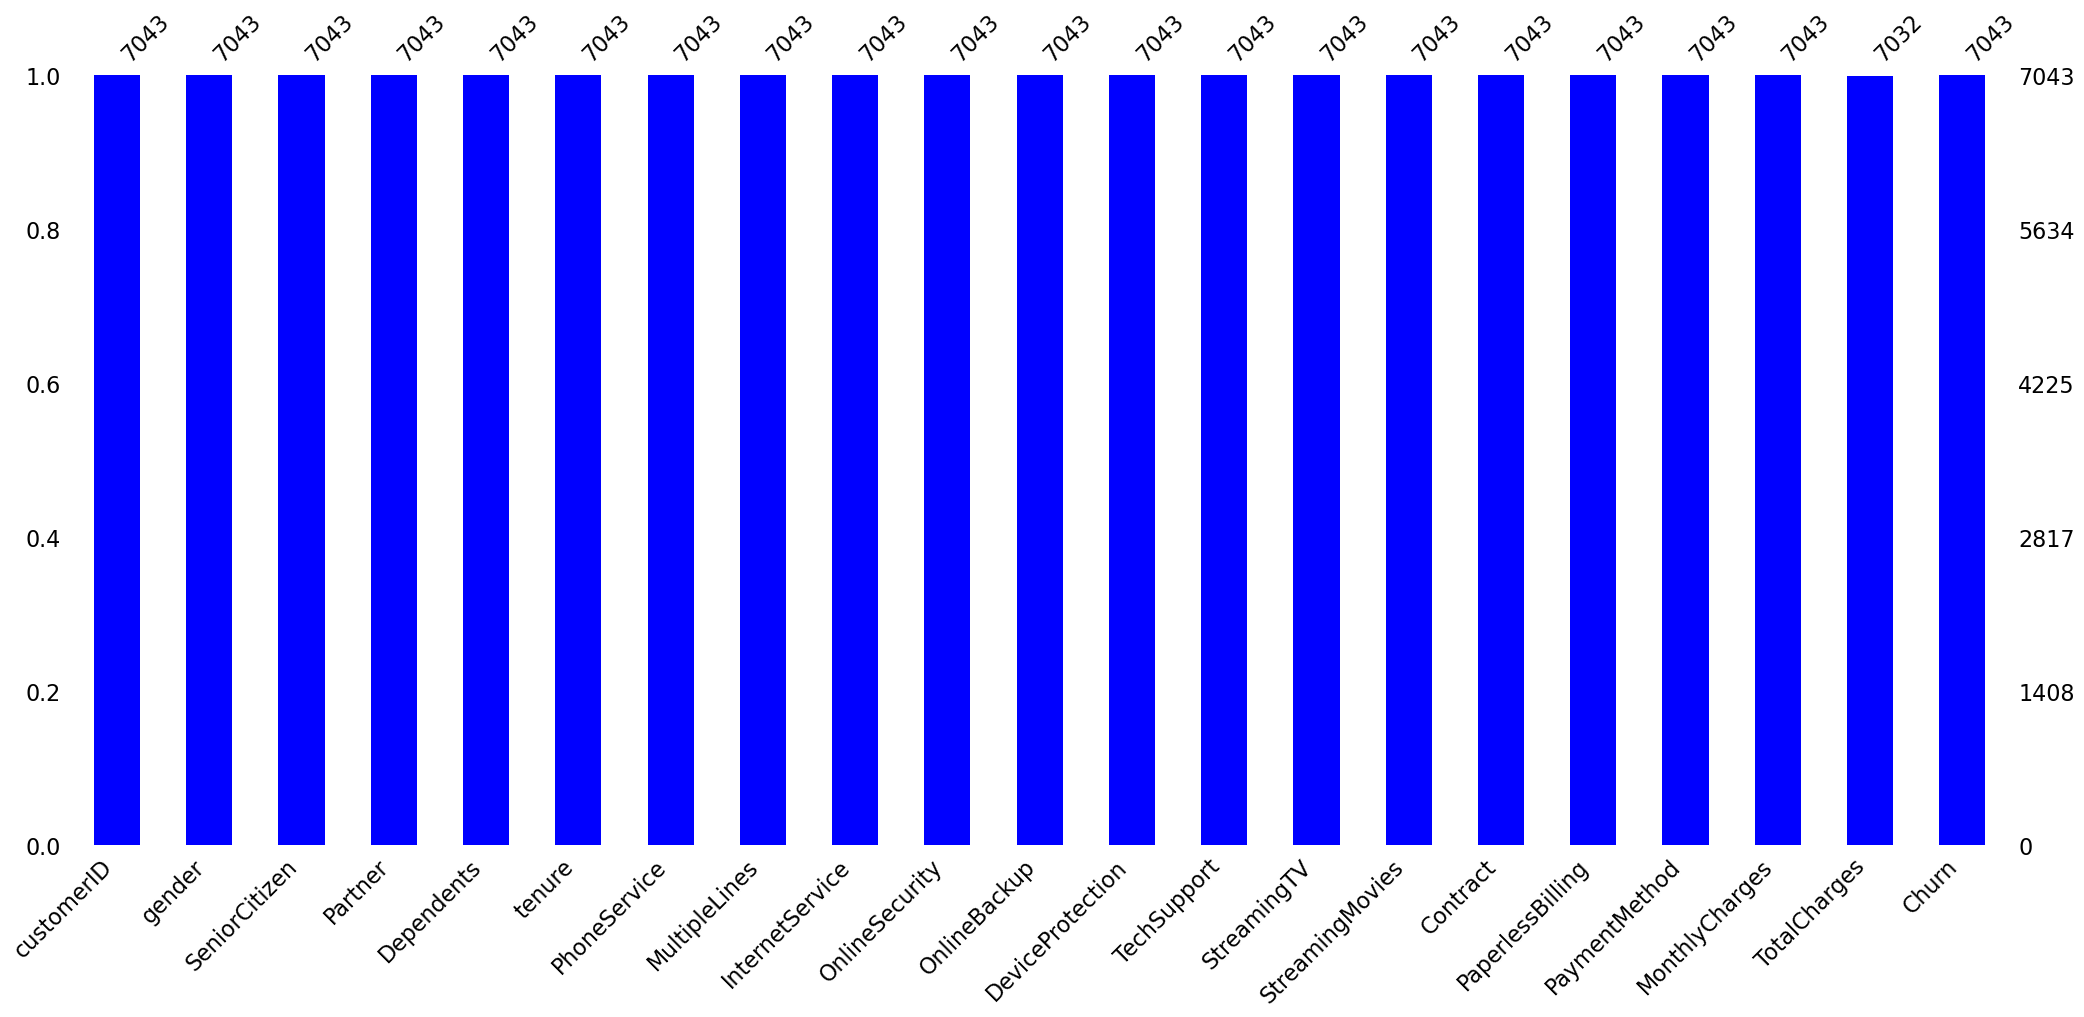

In [17]:
#visualizingthe missing data with bar plot
msno.bar(df, color = "Blue");

In [18]:
#priting the rows where there are missing data
print(df[df.isnull().any(axis=1)])

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
488   4472-LVYGI  Female              0     Yes        Yes       0   
753   3115-CZMZD    Male              0      No        Yes       0   
936   5709-LVOEQ  Female              0     Yes        Yes       0   
1082  4367-NUYAO    Male              0     Yes        Yes       0   
1340  1371-DWPAZ  Female              0     Yes        Yes       0   
3331  7644-OMVMY    Male              0     Yes        Yes       0   
3826  3213-VVOLG    Male              0     Yes        Yes       0   
4380  2520-SGTTA  Female              0     Yes        Yes       0   
5218  2923-ARZLG    Male              0     Yes        Yes       0   
6670  4075-WKNIU  Female              0     Yes        Yes       0   
6754  2775-SEFEE    Male              0      No        Yes       0   

     PhoneService     MultipleLines InternetService       OnlineSecurity  ...  \
488            No  No phone service             DSL                  Yes  ... 

In [19]:
# Dropping the rows with missing values
df = df.dropna()

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [21]:
# Check for duplicates based on all columns
duplicates = df[df.duplicated()].sum()
duplicates


customerID            0
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines         0
InternetService       0
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
Contract              0
PaperlessBilling      0
PaymentMethod         0
MonthlyCharges      0.0
TotalCharges        0.0
Churn                 0
dtype: object

In [22]:
# check for Missing data
null_vals = df.isnull().sum()
null_vals

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

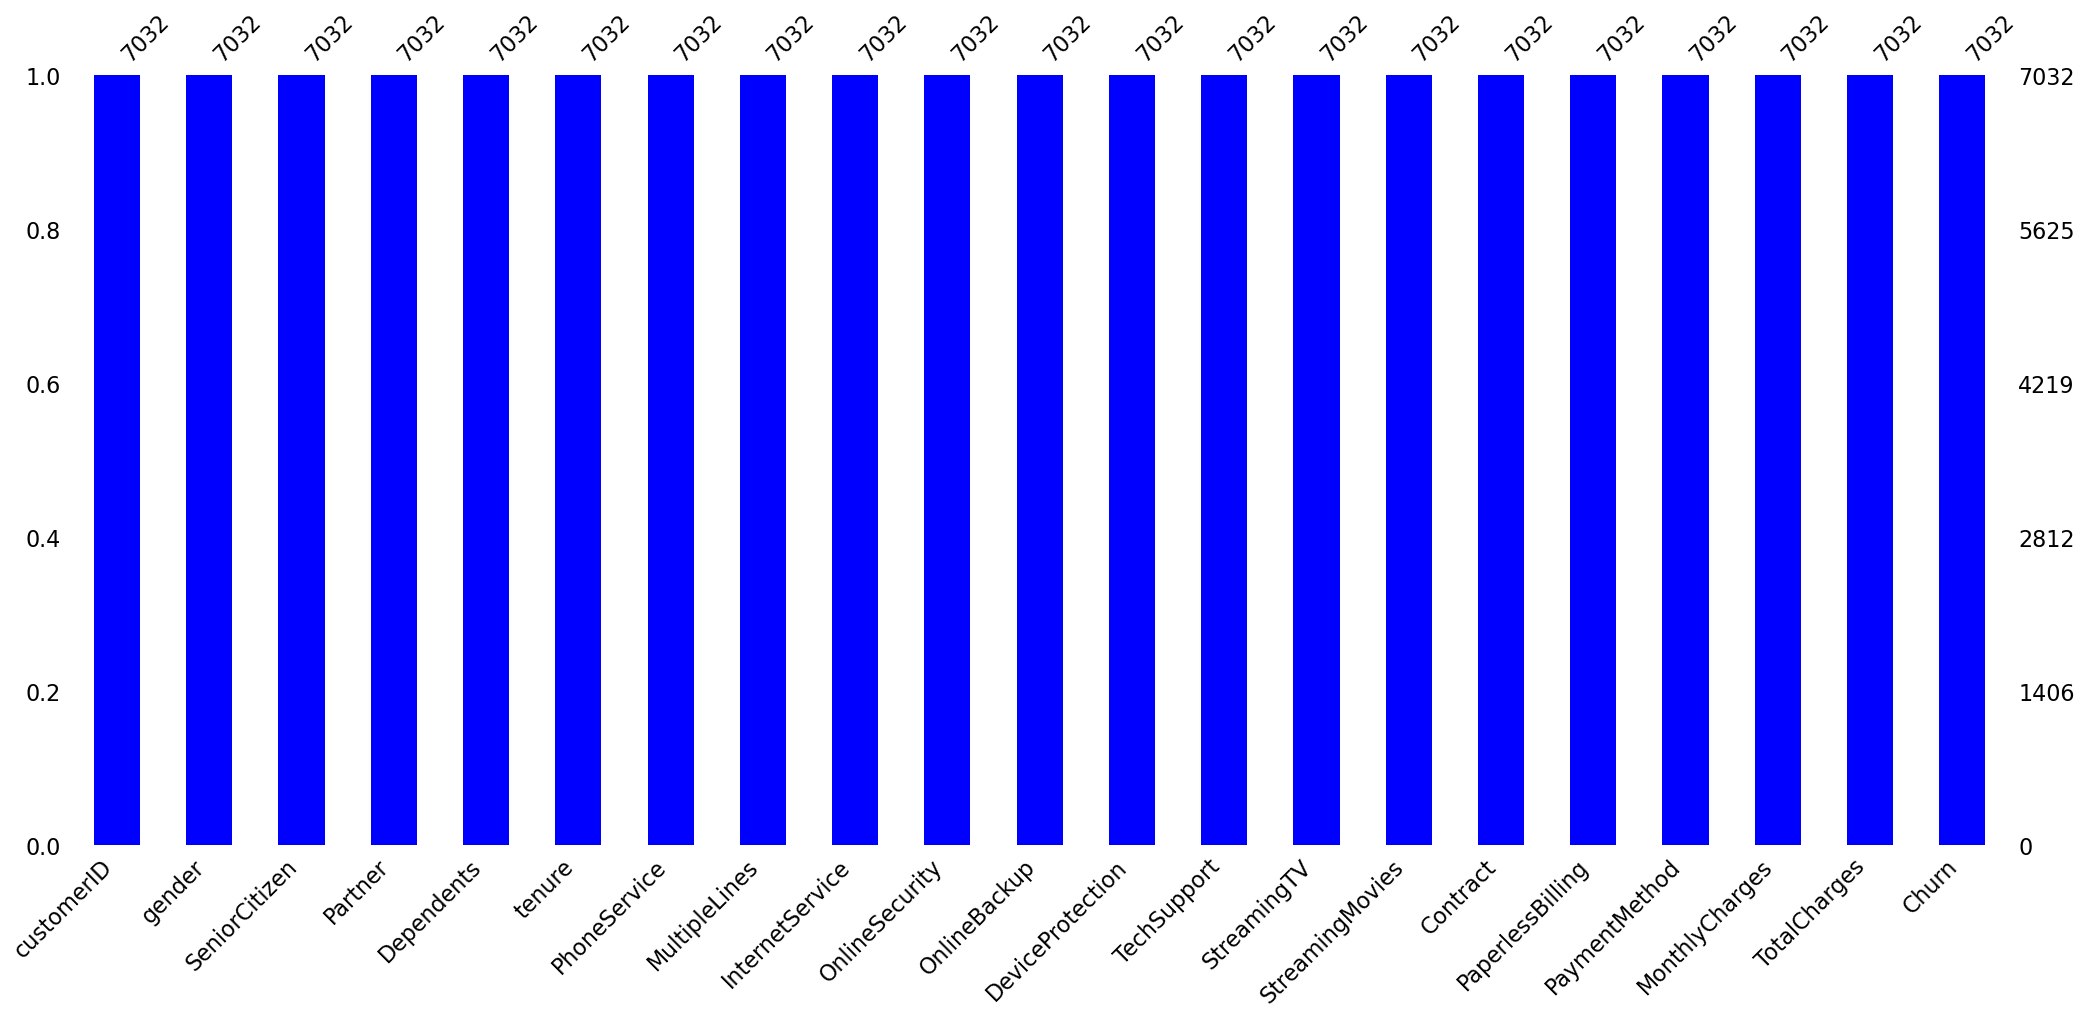

In [23]:
#visualizingthe missing data with bar plot
msno.bar(df, color = "Blue");

In [24]:
#df.describe(exclude = ["integer","float"])
df.describe(exclude = np.number).T

,count,unique,top,freq
customerID,7032,7032,7590-VHVEG,1
gender,7032,2,Male,3549
Partner,7032,2,No,3639
Dependents,7032,2,No,4933
PhoneService,7032,2,Yes,6352
MultipleLines,7032,3,No,3385
InternetService,7032,3,Fiber optic,3096
OnlineSecurity,7032,3,No,3497
OnlineBackup,7032,3,No,3087
DeviceProtection,7032,3,No,3094


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [26]:
# Datatime analysis
df.head(2)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


### Overview of Data - Univariate Analysis

In [27]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

## Population Census


In [28]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

<Axes: xlabel='SeniorCitizen'>

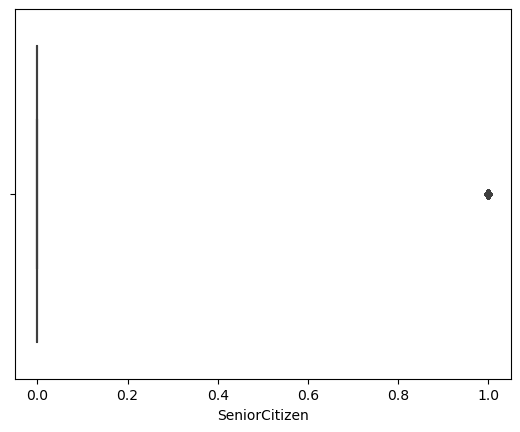

In [29]:
sns.boxplot(x=df["SeniorCitizen"])

<Axes: xlabel='tenure'>

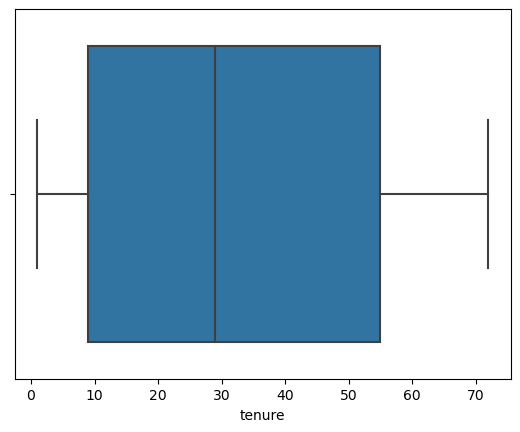

In [30]:
sns.boxplot(x=df["tenure"])

<Axes: xlabel='MonthlyCharges'>

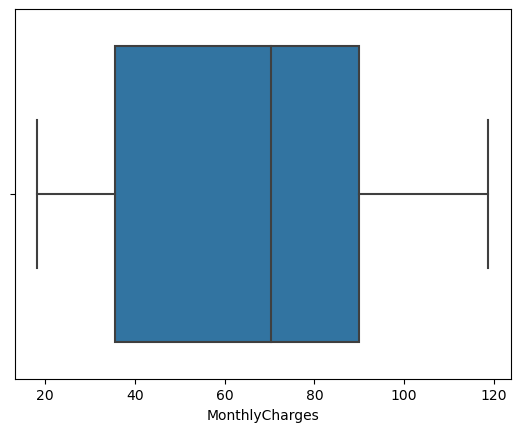

In [31]:
sns.boxplot(x=df["MonthlyCharges"])

<Axes: xlabel='TotalCharges'>

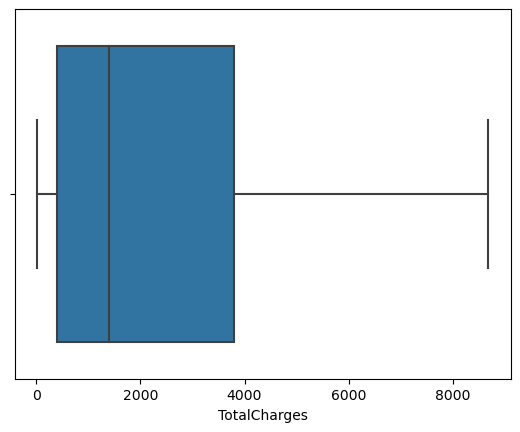

In [32]:
sns.boxplot(x=df["TotalCharges"])

<Axes: xlabel='tenure'>

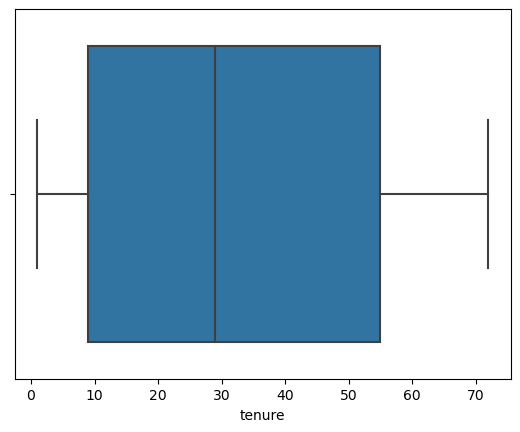

In [33]:
sns.boxplot(x=df["tenure"])

<Axes: xlabel='tenure'>

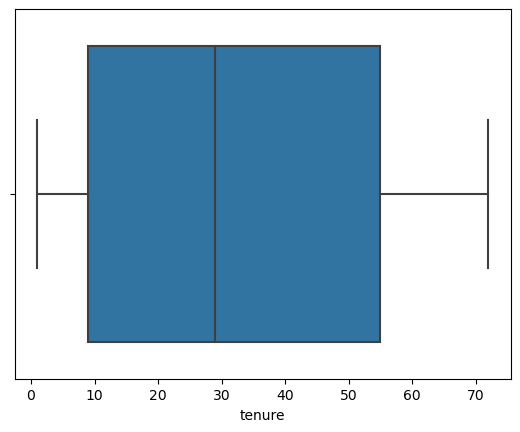

In [34]:
sns.boxplot(x=df["tenure"])

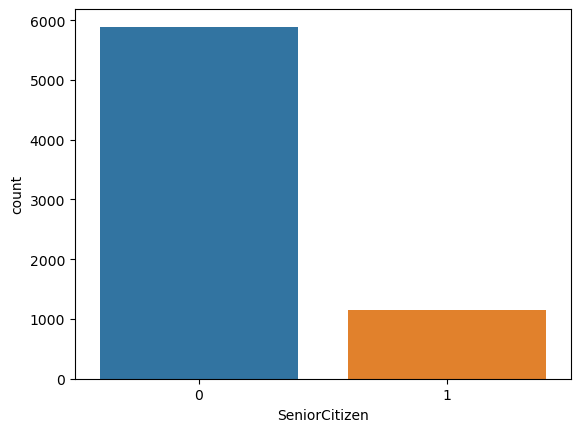

In [35]:
sns.countplot(x="SeniorCitizen", data=df);

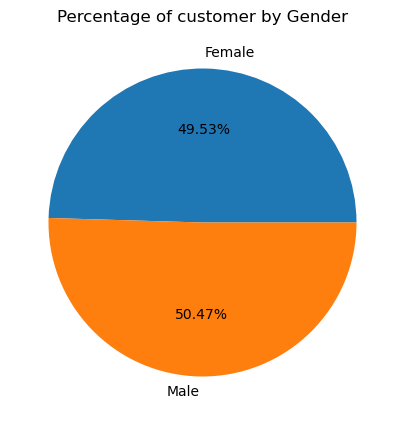

In [36]:
fig,ax = plt.subplots(figsize=(5,5))
count = Counter(df['gender'])
ax.pie(count.values(), labels=count.keys(), autopct=lambda p:f'{p:.2f}%')
ax.set_title("Percentage of customer by Gender")
plt.show();

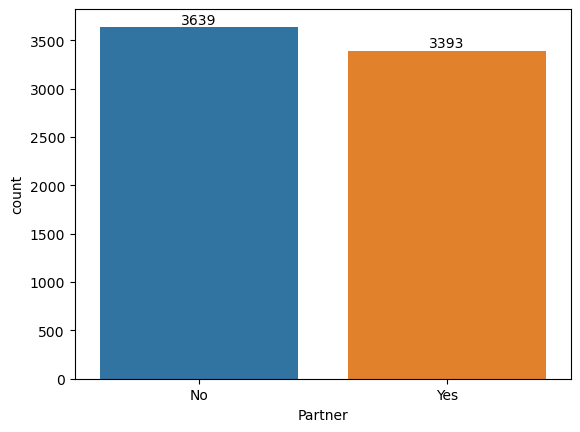

In [37]:
# Total numbers of partners customer

ax =sns.countplot(x=df["Partner"], order=df["Partner"].value_counts(ascending=False).index)
ax
values = df["Partner"].value_counts(ascending=False).values
ax.bar_label(container=ax.containers[0], labels=values);

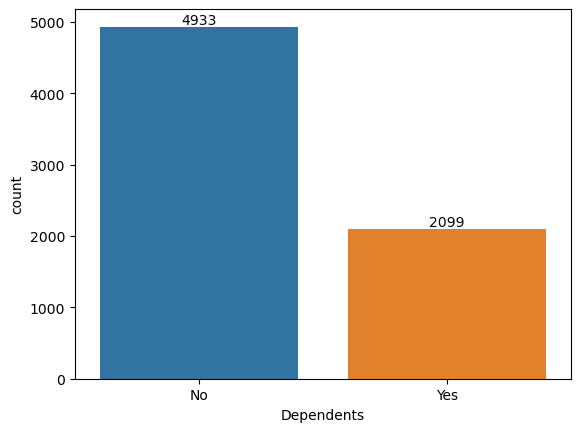

In [38]:
# Total numbers of Dependant

ax =sns.countplot(x=df["Dependents"], order=df["Dependents"].value_counts(ascending=False).index)
ax
values = df["Dependents"].value_counts(ascending=False).values
ax.bar_label(container=ax.containers[0], labels=values);

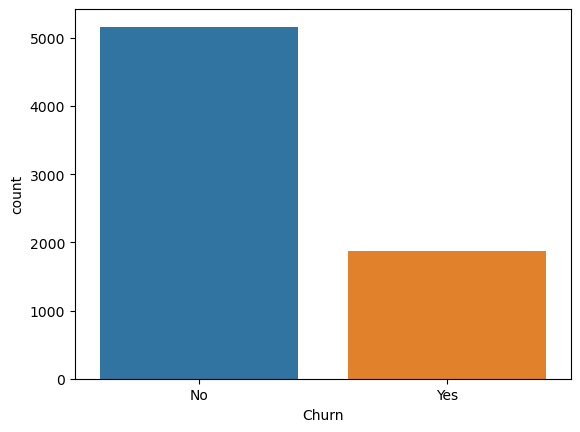

In [39]:
sns.countplot(x="Churn", data=df);


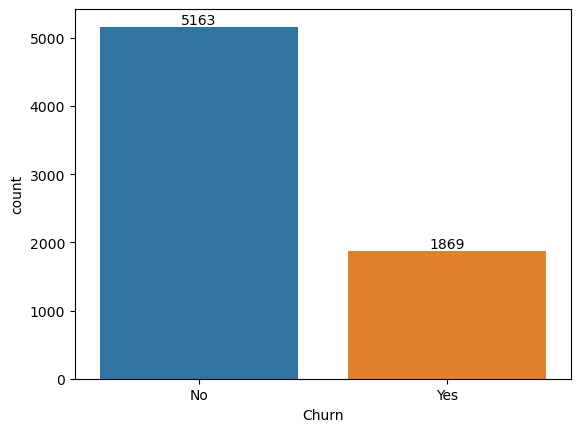

In [40]:
# Total numbers of churn rate

ax =sns.countplot(x=df["Churn"], order=df["Churn"].value_counts(ascending=False).index)
ax
values = df["Churn"].value_counts(ascending=False).values
ax.bar_label(container=ax.containers[0], labels=values);

## Subscriptions

In [41]:
# PhoneService
# InternetService
# MultipleLines
# StreamingTV
# StreamingMovie

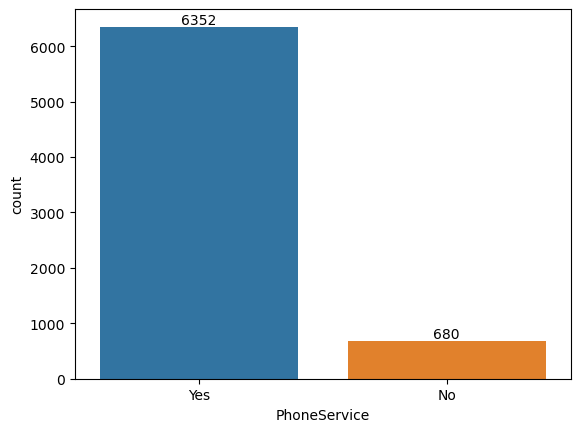

In [42]:
# Analysis by PhoneService Subscription

ax =sns.countplot(x=df["PhoneService"], order=df["PhoneService"].value_counts(ascending=False).index)
ax
values = df["PhoneService"].value_counts(ascending=False).values
ax.bar_label(container=ax.containers[0], labels=values);

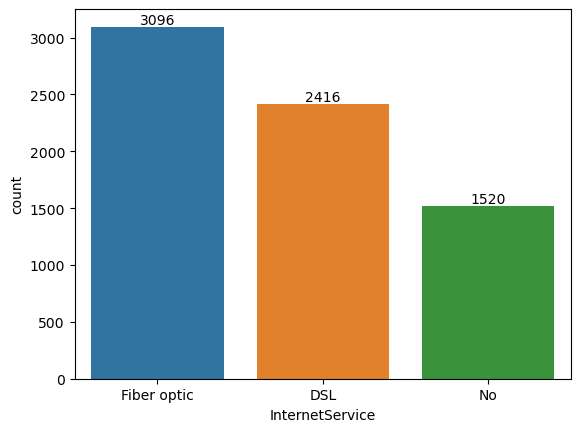

In [43]:
# Analysis by InternetService Subscription

ax =sns.countplot(x=df["InternetService"], order=df["InternetService"].value_counts(ascending=False).index)
ax
values = df["InternetService"].value_counts(ascending=False).values
ax.bar_label(container=ax.containers[0], labels=values);

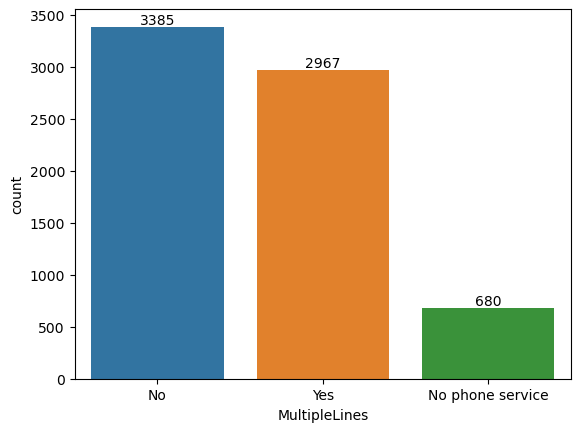

In [44]:
# Analysis by MultipleLines Subscription

ax =sns.countplot(x=df["MultipleLines"], order=df["MultipleLines"].value_counts(ascending=False).index)
ax
values = df["MultipleLines"].value_counts(ascending=False).values
ax.bar_label(container=ax.containers[0], labels=values);

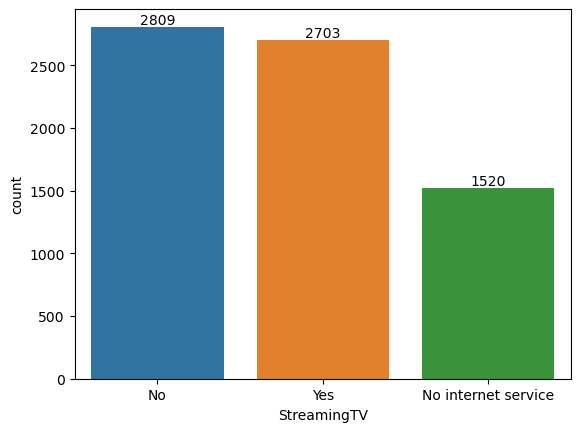

In [45]:
# Analysis by StreamingTV Subscription

ax =sns.countplot(x=df["StreamingTV"], order=df["StreamingTV"].value_counts(ascending=False).index)
ax
values = df["StreamingTV"].value_counts(ascending=False).values
ax.bar_label(container=ax.containers[0], labels=values);

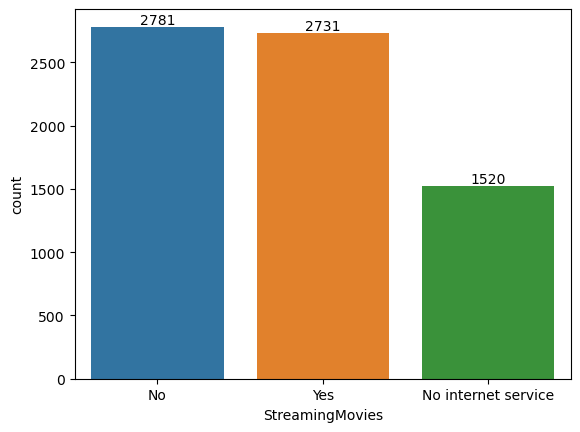

In [46]:
# Analysis by StreamingMovies Subscription

ax =sns.countplot(x=df["StreamingMovies"], order=df["StreamingMovies"].value_counts(ascending=False).index)
ax
values = df["StreamingMovies"].value_counts(ascending=False).values
ax.bar_label(container=ax.containers[0], labels=values);

## Service Charges

In [47]:
#fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(15,10))

service_charge = df.groupby("MonthlyCharges")["TotalCharges"].sum().reset_index()
service_charge

,MonthlyCharges,TotalCharges
0,18.25,534.70
1,18.40,1057.85
2,18.55,689.00
3,18.70,1389.35
4,18.75,53.15
...,...,...
1579,118.20,8547.15
1580,118.35,7804.15
1581,118.60,15355.75
1582,118.65,8477.60


# Bivariate Analysis

## Churn by Population Census

In [48]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

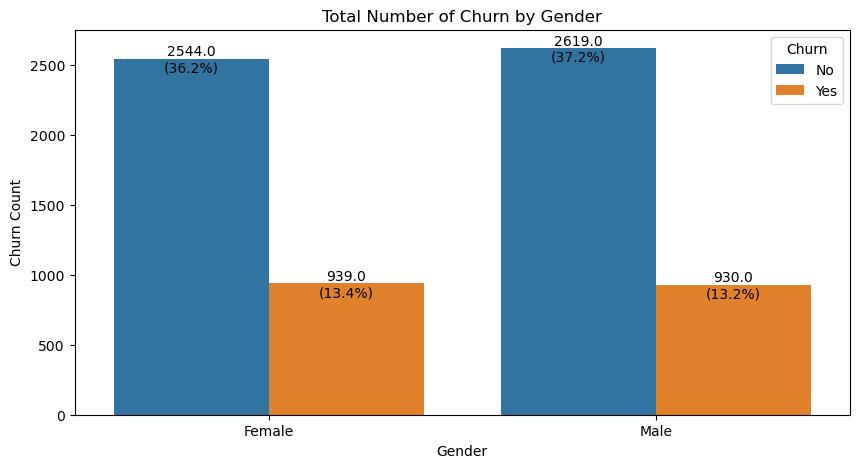

In [50]:
# churn by gender,  
plt.figure(figsize = (10, 5))
plot = sns.countplot(x='gender',  data=df, hue='Churn')

# Calculate Total counts for each hue (Churn)
total_counts = len(df)

# Add labels to each bar with both and percentage
for p in plot.patches:
    height = p.get_height()  # get the height count of the bar
    percentage = (height / total_counts)*100   # calculate percentage
    plot.annotate(f'{height}\n({percentage:.1f}%)', # Display count and percentage
                  (p.get_x() + 
p.get_width() / 2., height),  # Position the label
                  ha='center',
va='center_baseline',  # Center the label
                  xytext=(0, 1),  # Slightly offset the label from the bar
textcoords='offset points')
    
# Customize the plot
plt.xlabel('Gender')
plt.ylabel('Churn Count')
plt.title('Total Number of Churn by Gender')
 # Show plot
plt.show()

In [51]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

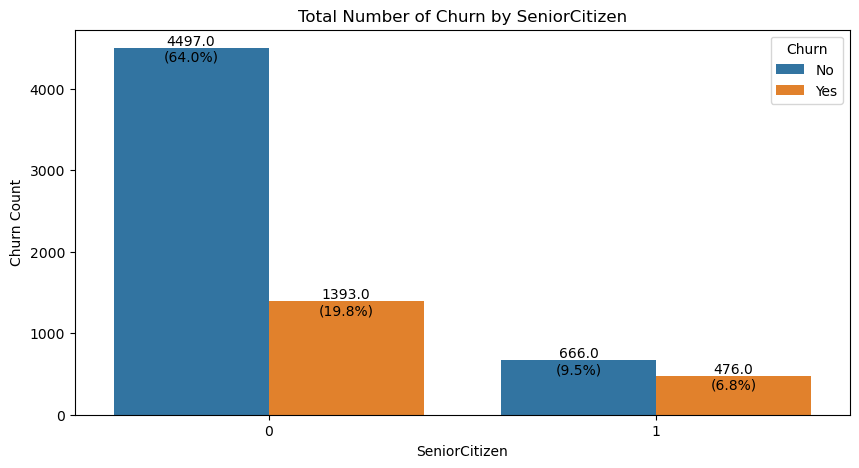

In [52]:
# churn by SeniorCitizen,  
plt.figure(figsize = (10, 5))
plot = sns.countplot(x='SeniorCitizen',  data=df, hue='Churn')

# Calculate Total counts for the entire dataset
total_counts = len(df)

# Add labels to each bar with both and percentage
for p in plot.patches:
    height = p.get_height()  # get the height count of the bar
    percentage = (height / total_counts)*100   # calculate percentage
    plot.annotate(f'{height}\n({percentage:.1f}%)', # Display count and percentage
                  (p.get_x() + 
p.get_width() / 2., height),  # Position the label
                  ha='center',
va='center_baseline',  # Center the label
                  xytext=(0, 1),  # Slightly offset the label from the bar
textcoords='offset points')
    
# Customize the plot
plt.xlabel('SeniorCitizen')
plt.ylabel('Churn Count')
plt.title('Total Number of Churn by SeniorCitizen')
 # Show plot
plt.show()

In [53]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

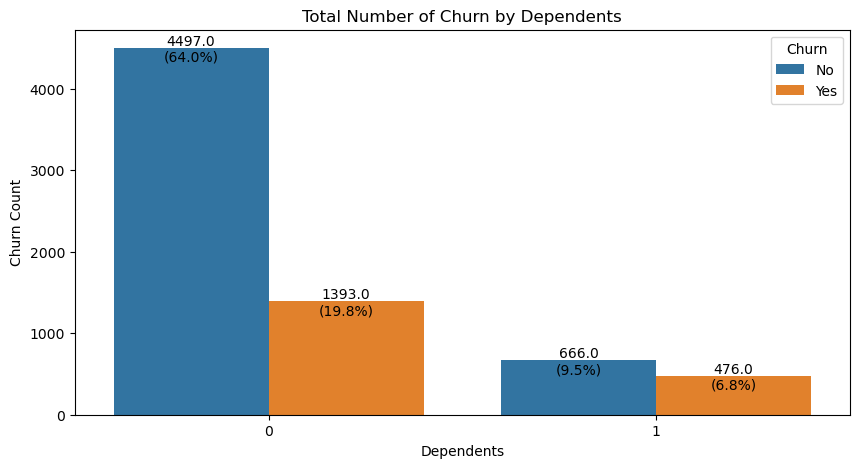

In [54]:
# churn by Dependents,  
plt.figure(figsize = (10, 5))
plot = sns.countplot(x='SeniorCitizen',  data=df, hue='Churn')

# Calculate Total counts for the entire dataset
total_counts = len(df)

# Add labels to each bar with both and percentage
for p in plot.patches:
    height = p.get_height()  # get the height count of the bar
    percentage = (height / total_counts)*100   # calculate percentage
    plot.annotate(f'{height}\n({percentage:.1f}%)', # Display count and percentage
                  (p.get_x() + 
p.get_width() / 2., height),  # Position the label
                  ha='center',
va='center_baseline',  # Center the label
                  xytext=(0, 1),  # Slightly offset the label from the bar
textcoords='offset points')
    
# Customize the plot
plt.xlabel('Dependents')
plt.ylabel('Churn Count')
plt.title('Total Number of Churn by Dependents')
 # Show plot
plt.show()


In [55]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

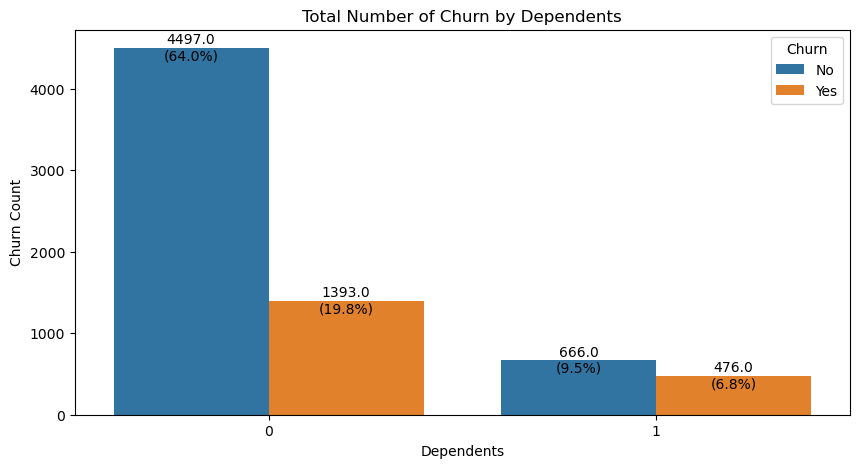

In [56]:
# churn by Dependents,  
plt.figure(figsize = (10, 5))
plot = sns.countplot(x='SeniorCitizen',  data=df, hue='Churn')

# Calculate Total counts for the entire dataset
total_counts = len(df)

# Add labels to each bar with both and percentage
for p in plot.patches:
    height = p.get_height()  # get the height count of the bar
    percentage = (height / total_counts)*100   # calculate percentage
    plot.annotate(f'{height}\n({percentage:.1f}%)', # Display count and percentage
                  (p.get_x() + 
p.get_width() / 2., height),  # Position the label
                  ha='center',
va='center_baseline',  # Center the label
                  xytext=(0, 2),  # Slightly offset the label from the bar
textcoords='offset points')
    
# Customize the plot
plt.xlabel('Dependents')
plt.ylabel('Churn Count')
plt.title('Total Number of Churn by Dependents')
 # Show plot
plt.show()


## Churn by Subscription

In [57]:
# PhoneService
# InternetService
# MultipleLines
# StreamingTV
# StreamingMovie

In [58]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

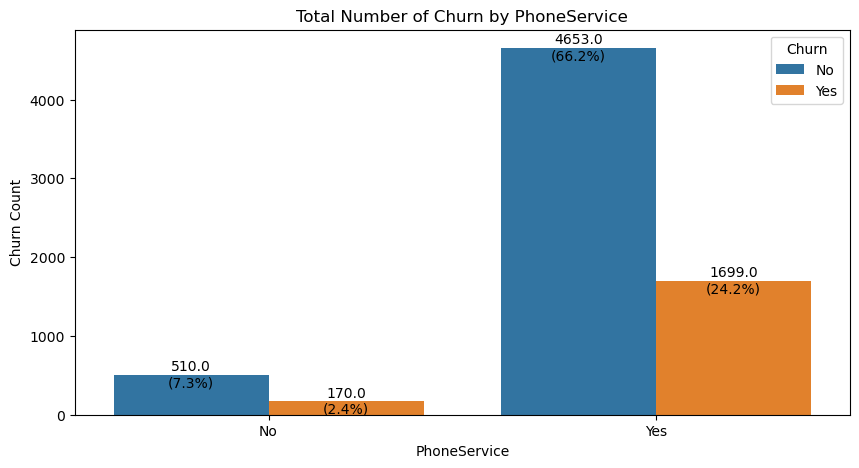

In [59]:
# churn by PhoneService,  
plt.figure(figsize = (10, 5))
plot = sns.countplot(x='PhoneService',  data=df, hue='Churn')

# Calculate Total counts for the entire dataset
total_counts = len(df)

# Add labels to each bar with both and percentage
for p in plot.patches:
    height = p.get_height()  # get the height count of the bar
    percentage = (height / total_counts)*100   # calculate percentage
    plot.annotate(f'{height}\n({percentage:.1f}%)', # Display count and percentage
                  (p.get_x() + 
p.get_width() / 2., height),  # Position the label
                  ha='center',
va='center_baseline',  # Center the label
                  xytext=(0, 2),  # Slightly offset the label from the bar
textcoords='offset points')
    
# Customize the plot
plt.xlabel('PhoneService')
plt.ylabel('Churn Count')
plt.title('Total Number of Churn by PhoneService')
 # Show plot
plt.show()

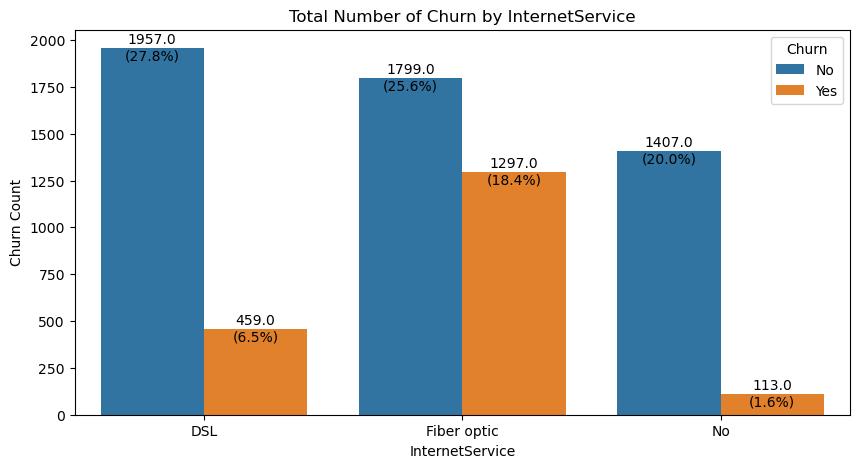

In [60]:
# churn by InternetService,  
plt.figure(figsize = (10, 5))
plot = sns.countplot(x='InternetService',  data=df, hue='Churn')

# Calculate Total counts for the entire dataset
total_counts = len(df)

# Add labels to each bar with both and percentage
for p in plot.patches:
    height = p.get_height()  # get the height count of the bar
    percentage = (height / total_counts)*100   # calculate percentage
    plot.annotate(f'{height}\n({percentage:.1f}%)', # Display count and percentage
                  (p.get_x() + 
p.get_width() / 2., height),  # Position the label
                  ha='center',
va='center_baseline',  # Center the label
                  xytext=(0, 2),  # Slightly offset the label from the bar
textcoords='offset points')
    
# Customize the plot
plt.xlabel('InternetService')
plt.ylabel('Churn Count')
plt.title('Total Number of Churn by InternetService')
 # Show plot
plt.show()


In [61]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

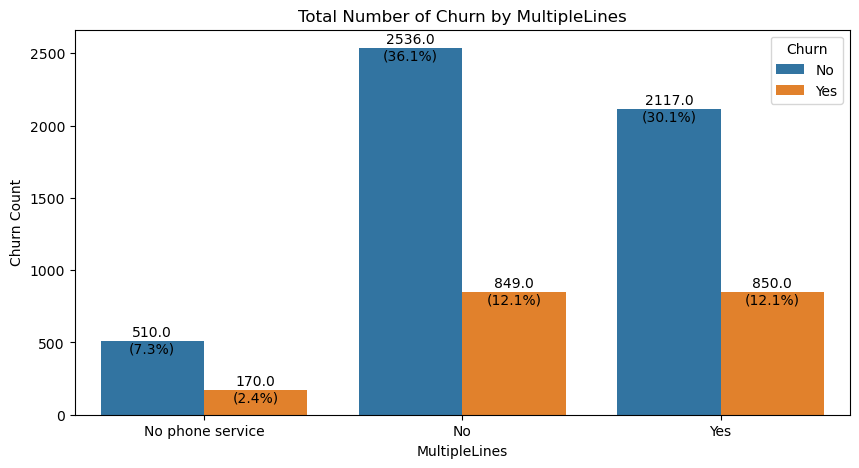

In [62]:
#churn by MultipleLines,  
plt.figure(figsize = (10, 5))
plot = sns.countplot(x='MultipleLines',  data=df, hue='Churn')

# Calculate Total counts for the entire dataset
total_counts = len(df)

# Add labels to each bar with both and percentage
for p in plot.patches:
    height = p.get_height()  # get the height count of the bar
    percentage = (height / total_counts)*100   # calculate percentage
    plot.annotate(f'{height}\n({percentage:.1f}%)', # Display count and percentage
                  (p.get_x() + 
p.get_width() / 2., height),  # Position the label
                  ha='center',
va='center_baseline',  # Center the label
                  xytext=(0, 2),  # Slightly offset the label from the bar
textcoords='offset points')
    
# Customize the plot
plt.xlabel('MultipleLines')
plt.ylabel('Churn Count')
plt.title('Total Number of Churn by MultipleLines')
 # Show plot
plt.show()


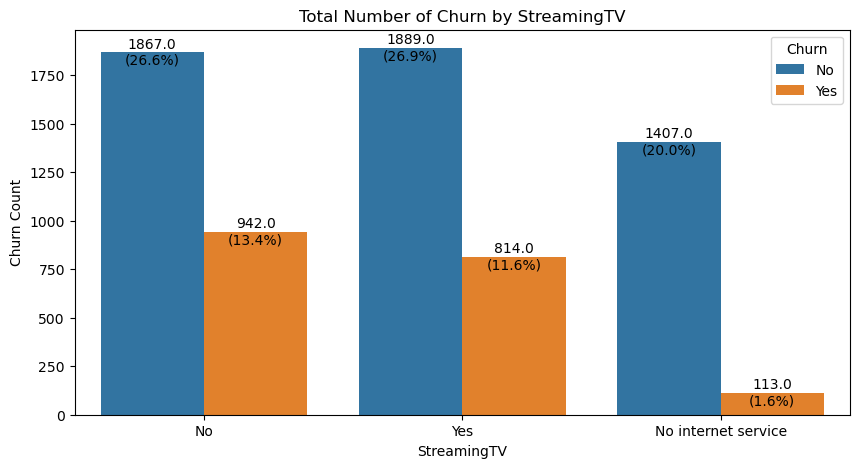

In [63]:
#churn by StreamingTV,  
plt.figure(figsize = (10, 5))
plot = sns.countplot(x='StreamingTV',  data=df, hue='Churn')

# Calculate Total counts for the entire dataset
total_counts = len(df)

# Add labels to each bar with both and percentage
for p in plot.patches:
    height = p.get_height()  # get the height count of the bar
    percentage = (height / total_counts)*100   # calculate percentage
    plot.annotate(f'{height}\n({percentage:.1f}%)', # Display count and percentage
                  (p.get_x() + 
p.get_width() / 2., height),  # Position the label
                  ha='center',
va='center_baseline',  # Center the label
                  xytext=(0, 2),  # Slightly offset the label from the bar
textcoords='offset points')
    
# Customize the plot
plt.xlabel('StreamingTV')
plt.ylabel('Churn Count')
plt.title('Total Number of Churn by StreamingTV')
 # Show plot
plt.show()

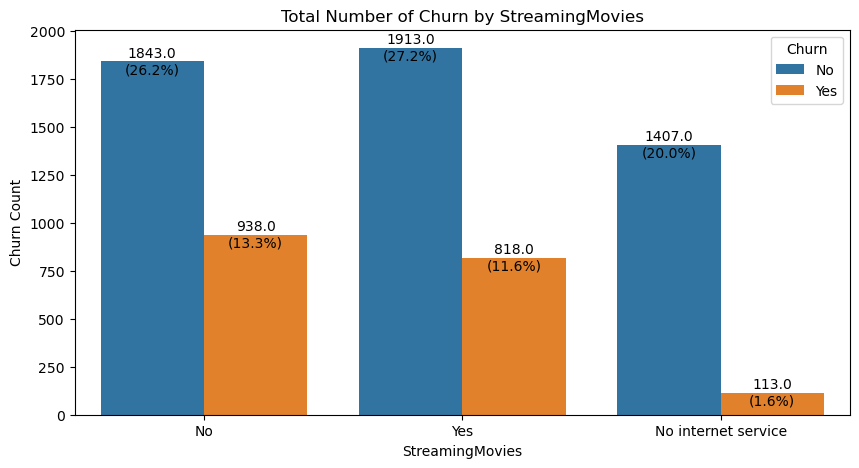

In [64]:
#churn by StreamingMovies,  
plt.figure(figsize = (10, 5))
plot = sns.countplot(x='StreamingMovies',  data=df, hue='Churn')

# Calculate Total counts for the entire dataset
total_counts = len(df)

# Add labels to each bar with both and percentage
for p in plot.patches:
    height = p.get_height()  # get the height count of the bar
    percentage = (height / total_counts)*100   # calculate percentage
    plot.annotate(f'{height}\n({percentage:.1f}%)', # Display count and percentage
                  (p.get_x() + 
p.get_width() / 2., height),  # Position the label
                  ha='center',
va='center_baseline',  # Center the label
                  xytext=(0, 2),  # Slightly offset the label from the bar
textcoords='offset points')
    
# Customize the plot
plt.xlabel('StreamingMovies')
plt.ylabel('Churn Count')
plt.title('Total Number of Churn by StreamingMovies')
 # Show plot
plt.show()

## Churn by Service Charges

In [65]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

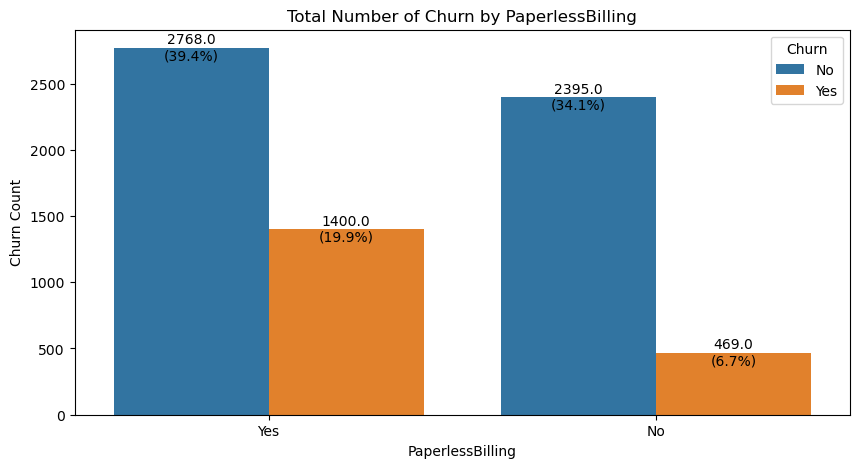

In [66]:
#churn by PaperlessBilling,  
plt.figure(figsize = (10, 5))
plot = sns.countplot(x='PaperlessBilling',  data=df, hue='Churn')

# Calculate Total counts for the entire dataset
total_counts = len(df)

# Add labels to each bar with both and percentage
for p in plot.patches:
    height = p.get_height()  # get the height count of the bar
    percentage = (height / total_counts)*100   # calculate percentage
    plot.annotate(f'{height}\n({percentage:.1f}%)', # Display count and percentage
                  (p.get_x() + 
p.get_width() / 2., height),  # Position the label
                  ha='center',
va='center_baseline',  # Center the label
                  xytext=(0, 2),  # Slightly offset the label from the bar
textcoords='offset points')
    
# Customize the plot
plt.xlabel('PaperlessBilling')
plt.ylabel('Churn Count')
plt.title('Total Number of Churn by PaperlessBilling')
 # Show plot
plt.show()

In [67]:
# Product category against cost, Revenue and profit



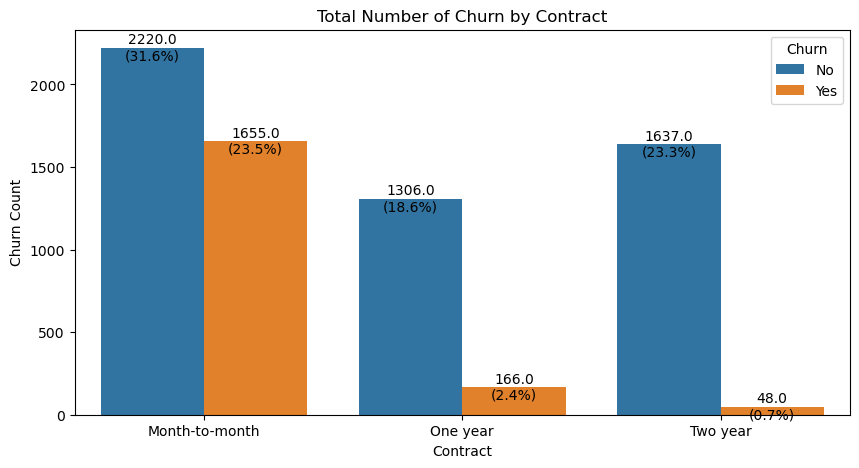

In [68]:
#churn by Contract,  
plt.figure(figsize = (10, 5))
plot = sns.countplot(x='Contract',  data=df, hue='Churn')

# Calculate Total counts for the entire dataset
total_counts = len(df)

# Add labels to each bar with both and percentage
for p in plot.patches:
    height = p.get_height()  # get the height count of the bar
    percentage = (height / total_counts)*100   # calculate percentage
    plot.annotate(f'{height}\n({percentage:.1f}%)', # Display count and percentage
                  (p.get_x() + 
p.get_width() / 2., height),  # Position the label
                  ha='center',
va='center_baseline',  # Center the label
                  xytext=(0, 2),  # Slightly offset the label from the bar
textcoords='offset points')
    
# Customize the plot
plt.xlabel('Contract')
plt.ylabel('Churn Count')
plt.title('Total Number of Churn by Contract')
 # Show plot
plt.show()

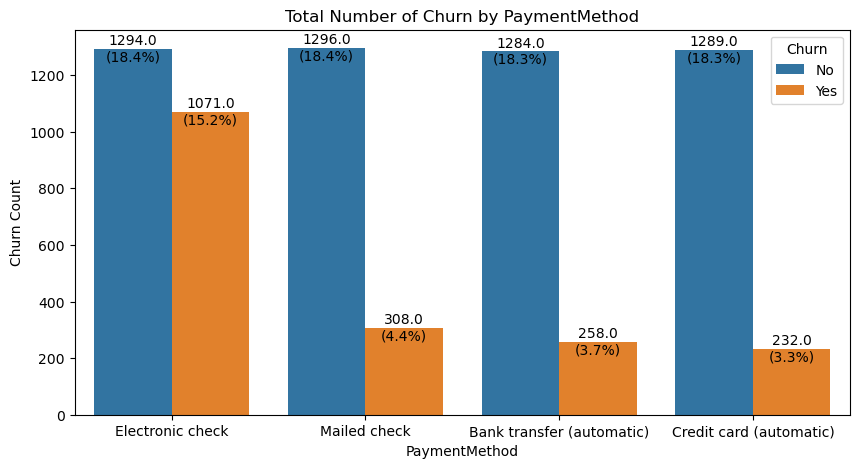

In [69]:
#churn by PaymentMethod,  
plt.figure(figsize = (10, 5))
plot = sns.countplot(x='PaymentMethod',  data=df, hue='Churn')

# Calculate Total counts for the entire dataset
total_counts = len(df)

# Add labels to each bar with both and percentage
for p in plot.patches:
    height = p.get_height()  # get the height count of the bar
    percentage = (height / total_counts)*100   # calculate percentage
    plot.annotate(f'{height}\n({percentage:.1f}%)', # Display count and percentage
                  (p.get_x() + 
p.get_width() / 2., height),  # Position the label
                  ha='center',
va='center_baseline',  # Center the label
                  xytext=(0, 2),  # Slightly offset the label from the bar
textcoords='offset points')
    
# Customize the plot
plt.xlabel('PaymentMethod')
plt.ylabel('Churn Count')
plt.title('Total Number of Churn by PaymentMethod')
 # Show plot
plt.show()

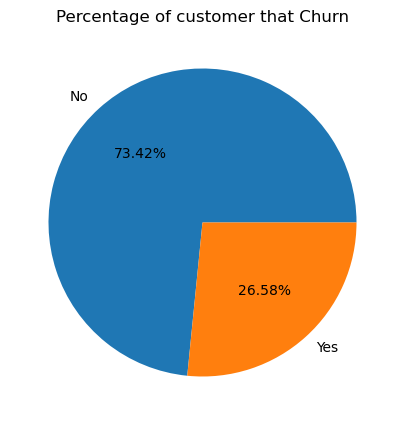

In [70]:
fig,ax = plt.subplots(figsize=(5,5))
count = Counter(df['Churn'])
ax.pie(count.values(), labels=count.keys(), autopct=lambda p:f'{p:.2f}%')
ax.set_title("Percentage of customer that Churn")
plt.show();

In [71]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

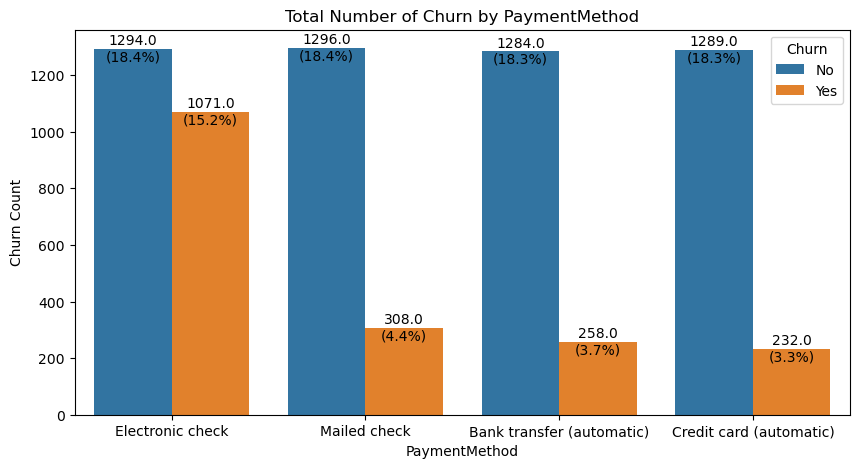

In [72]:
#churn by PaymentMethod,  
plt.figure(figsize = (10, 5))
plot = sns.countplot(x='PaymentMethod',  data=df, hue='Churn')

# Calculate Total counts for the entire dataset
total_counts = len(df)

# Add labels to each bar with both and percentage
for p in plot.patches:
    height = p.get_height()  # get the height count of the bar
    percentage = (height / total_counts)*100   # calculate percentage
    plot.annotate(f'{height}\n({percentage:.1f}%)', # Display count and percentage
                  (p.get_x() + 
p.get_width() / 2., height),  # Position the label
                  ha='center',
va='center_baseline',  # Center the label
                  xytext=(0, 2),  # Slightly offset the label from the bar
textcoords='offset points')
    
# Customize the plot
plt.xlabel('PaymentMethod')
plt.ylabel('Churn Count')
plt.title('Total Number of Churn by PaymentMethod')
 # Show plot
plt.show()

In [73]:
Naration about the visualization

SyntaxError: invalid syntax (2266067288.py, line 1)

### Exploratory Data Analysis - Multivariate Analysis

In [74]:
numeric_df= df.select_dtypes(include=[float, int])

In [75]:
corr_matrix = numeric_df.corr()

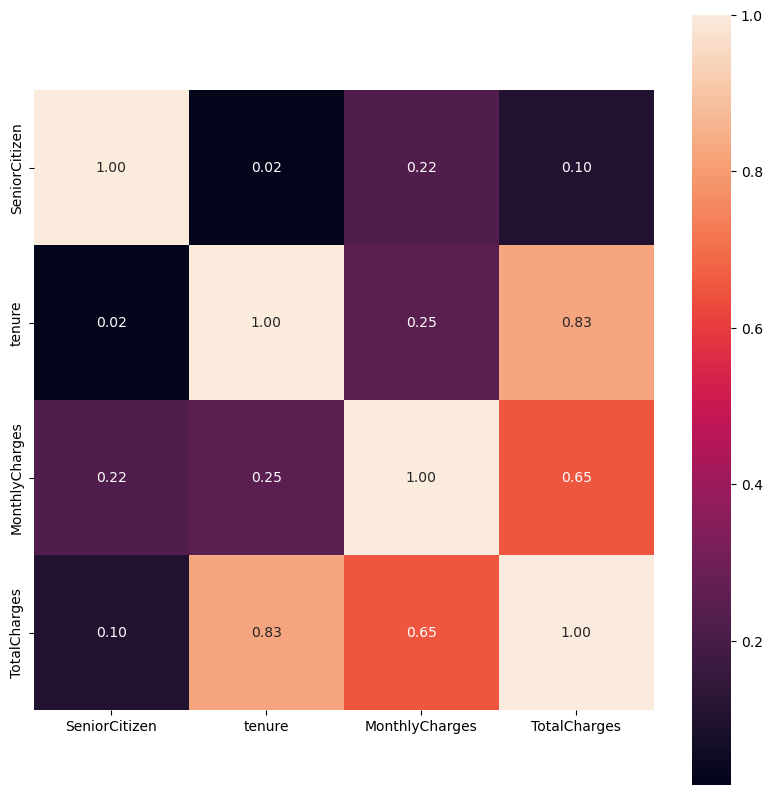

In [76]:
plt.figure(figsize = (10,10))
hm = sns.heatmap(corr_matrix, cbar=True, annot=True, square=True, fmt='.2f',
                 annot_kws ={'size':10})
plt.show()

 ##  Feature Engineering / Data _ preprocessing

In [77]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [78]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [79]:


cat_features = df.drop(["customerID","SeniorCitizen","tenure","MonthlyCharges","TotalCharges"],axis=1)
cat_features.head()

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,No
1,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,No
2,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,Yes
3,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),No
4,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes


In [80]:
#Encode categorical features to a numerical feature
from sklearn import preprocessing
cat_num = preprocessing.LabelEncoder()
df_cat = cat_features.apply(cat_num.fit_transform)
df_cat.head()

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,0,1,0,0,1,0,0,2,0,0,0,0,0,1,2,0
1,1,0,0,1,0,0,2,0,2,0,0,0,1,0,3,0
2,1,0,0,1,0,0,2,2,0,0,0,0,0,1,3,1
3,1,0,0,0,1,0,2,0,2,2,0,0,1,0,0,0
4,0,0,0,1,0,1,0,0,0,0,0,0,0,1,2,1


In [81]:
# Merge both the numerical features and the encoded  categorical features
num_features = df[["customerID","SeniorCitizen","tenure","MonthlyCharges","TotalCharges"]]
df_merge = pd.merge(num_features, df_cat, left_index=True, right_index=True)
df_merge.head()

,customerID,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender,Partner,Dependents,PhoneService,MultipleLines,...,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,7590-VHVEG,0,1,29.85,29.85,0,1,0,0,1,...,0,2,0,0,0,0,0,1,2,0
1,5575-GNVDE,0,34,56.95,1889.50,1,0,0,1,0,...,2,0,2,0,0,0,1,0,3,0
2,3668-QPYBK,0,2,53.85,108.15,1,0,0,1,0,...,2,2,0,0,0,0,0,1,3,1
3,7795-CFOCW,0,45,42.30,1840.75,1,0,0,0,1,...,2,0,2,2,0,0,1,0,0,0
4,9237-HQITU,0,2,70.70,151.65,0,0,0,1,0,...,0,0,0,0,0,0,0,1,2,1


In [82]:
df_merge.tail()

,customerID,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender,Partner,Dependents,PhoneService,MultipleLines,...,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
7038,6840-RESVB,0,24,84.80,1990.50,1,1,1,1,2,...,2,0,2,2,2,2,1,1,3,0
7039,2234-XADUH,0,72,103.20,7362.90,0,1,1,1,2,...,0,2,2,0,2,2,1,1,1,0
7040,4801-JZAZL,0,11,29.60,346.45,0,1,1,0,1,...,2,0,0,0,0,0,0,1,2,0
7041,8361-LTMKD,1,4,74.40,306.60,1,1,0,1,2,...,0,0,0,0,0,0,0,1,3,1
7042,3186-AJIEK,0,66,105.65,6844.50,1,0,0,1,0,...,2,0,2,2,2,2,2,1,0,0


In [83]:
# Droping redundant data features
df1 = df_merge.drop(columns = ["customerID"])

In [84]:
# Segment dataset into data and target label
target = df1.pop("Churn")

In [85]:
# Scaling the dataset features 
from sklearn.preprocessing import MinMaxScaler,StandardScaler

# Instantiatiating the scaler object
scaler = MinMaxScaler()

ds_scaled = pd.DataFrame(scaler.fit_transform(df1),columns=df1.columns)

# Identifying key features from the data set
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(ds_scaled, target)
importances = model.feature_importances_
sort_imp = np.argsort(importances)
name = list(df1.columns)



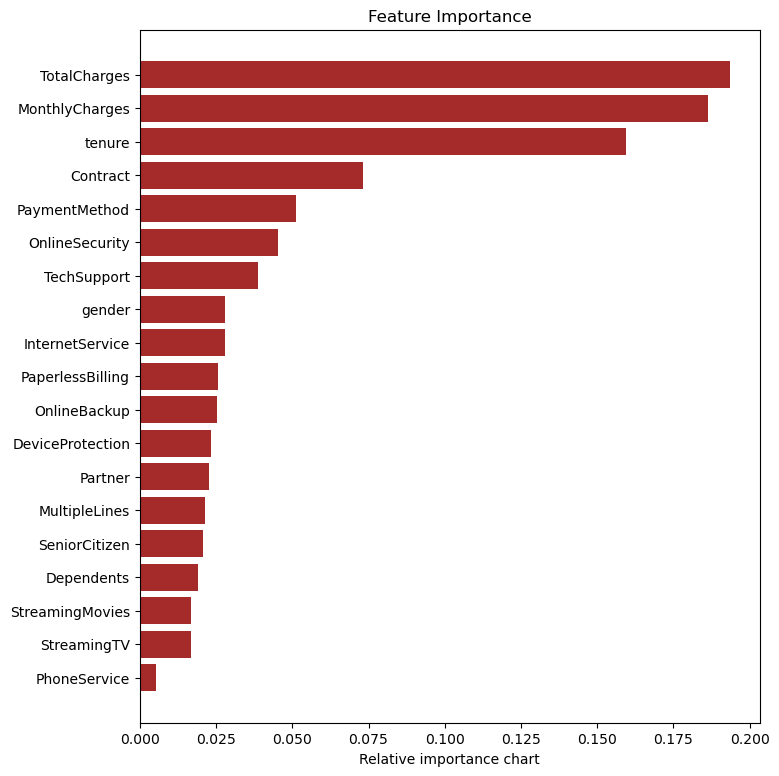

In [86]:
# Plotting a feature importance chart
plt.figure(figsize = (8,9))
plt.barh(range(len(sort_imp)), importances[sort_imp], color = "brown")
plt.yticks(range(len(sort_imp)),(name[x] for x in sort_imp))
plt.xlabel("Relative importance chart")
plt.title("Feature Importance")
plt.show()

## Machine Learning



#### Split data into training and testing dataset
#### Oversample the dataset because the dataset is imbalance
#### Implement machine learning / model building and training
#### Then create a prediction file

In [91]:
import sklearn 
print(sklearn.__version__)

1.5.2


In [88]:
!pip install -U scikit-learn

In [92]:
!pip install imbalanced-learn

In [93]:
#Split Data set into training and Testing X=Question, y=Answer
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(ds_scaled, target, test_size=0.2, random_state=42)

In [94]:
X_train.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
6021,0.0,0.591549,0.306468,0.237411,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.000000
3404,0.0,0.028169,0.349751,0.019605,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.333333
5474,0.0,0.760563,0.592040,0.512272,0.0,1.0,0.0,1.0,1.0,0.5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.666667
5515,0.0,0.619718,0.362189,0.292511,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.000000
6328,0.0,0.760563,0.822388,0.626564,0.0,1.0,1.0,1.0,1.0,0.5,1.0,0.0,0.0,0.0,1.0,1.0,0.5,0.0,1.000000


In [95]:
y_train.head()

6030    1
3410    1
5483    1
5524    0
6337    0
Name: Churn, dtype: int32

In [96]:
y_train.value_counts()

Churn
0    4130
1    1495
Name: count, dtype: int64

In [97]:
!pip install --upgrade scikit-learn

In [98]:

!pip install imbalanced-learn

In [99]:
!conda install -c conda-forge imbalanced-learn

Retrieving notices: ...working... done
Solving environment: ...working... done

# All requested packages already installed.





==> WARNING: A newer version of conda exists. <==
  current version: 23.7.4
  latest version: 24.9.1

Please update conda by running

    $ conda update -n base -c defaults conda

Or to minimize the number of packages updated during conda update use

     conda install conda=24.9.1




In [100]:
from imblearn.over_sampling import SMOTE

oversample = SMOTE (k_neighbors=5)
X_smote, y_smote = oversample.fit_resample(X_train, y_train)
X_train, y_train = X_smote, y_smote

In [101]:
y_train.value_counts()

Churn
1    4130
0    4130
Name: count, dtype: int64

## Model Buiding


In [102]:
classifiers = [
    [SVC(), "SVC"],
    [RandomForestClassifier(), "Random Forest"],
    [LogisticRegression(), "Logistic Regression"],
    [XGBClassifier(), "XGB Classifiers"],
    [SGDClassifier(), "SGD Classifier" ],
    [GaussianNB(), "Naive Bayes"],
    [DecisionTreeClassifier(), "Decision Tree"]
]

In [103]:
from sklearn.model_selection import GridSearchCV

In [104]:
from sklearn.metrics import classification_report, confusion_matrix

acc_list = {}
f_list = {}
roc_list = {}
precision_list = {}
recall_list = {}
confusion_matrix_list = {}

for classifier in classifiers:
    model = classifier[0]
    model.fit(X_train, y_train)
    model_name = classifier[1]
    X_test_contiguous = np.ascontiguousarray(X_test)
    pred = model.predict(X_test_contiguous)
    a_score = accuracy_score(y_test, pred)
    f_score = f1_score(y_test, pred)
    roc_score = roc_auc_score(y_test, pred)
    p_score = precision_score(y_test, pred)
    r_score = recall_score(y_test, pred)
    confusion_matrix_score = confusion_matrix(y_test, pred)
    tn,fp,tn,tp = confusion_matrix_score.ravel()
    confusion_matrix_list.update({model_name: confusion_matrix_score})
    
    
    print(f"Classifier: {model_name}")
    print(f"Accuracy: {a_score*100:.2f}%")
    print(f"F1 Score: {f_score*100:.2f}%")
    print(f"ROC AUC: {roc_score*100:.2f}%")
    print(f"Precision: {p_score*100:.2f}%")
    print(f"Recall: {r_score*100:.2f}%")
    print("Confusion  Matrix:")
    print(pd.DataFrame(confusion_matrix_score / confusion_matrix_score.sum(axis=1)[:, np.newaxis]*100).round(2).to_string(formatters={'float': lambda  x: f"{x:.2f}%"}))
    

Classifier: SVC
Accuracy: 75.76%
F1 Score: 60.67%
ROC AUC: 74.03%
Precision: 53.35%
Recall: 70.32%
Confusion  Matrix:
       0      1
0  77.73  22.27
1  29.68  70.32
Classifier: Random Forest
Accuracy: 76.69%
F1 Score: 57.07%
ROC AUC: 70.82%
Precision: 55.90%
Recall: 58.29%
Confusion  Matrix:
       0      1
0  83.35  16.65
1  41.71  58.29
Classifier: Logistic Regression
Accuracy: 74.13%
F1 Score: 62.00%
ROC AUC: 75.81%
Precision: 50.86%
Recall: 79.41%
Confusion  Matrix:
       0      1
0  72.22  27.78
1  20.59  79.41
Classifier: XGB Classifiers
Accuracy: 76.83%
F1 Score: 58.21%
ROC AUC: 71.68%
Precision: 55.91%
Recall: 60.70%
Confusion  Matrix:
       0      1
0  82.67  17.33
1  39.30  60.70
Classifier: SGD Classifier
Accuracy: 74.27%
F1 Score: 61.57%
ROC AUC: 75.31%
Precision: 51.06%
Recall: 77.54%
Confusion  Matrix:
       0      1
0  73.09  26.91
1  22.46  77.54
Classifier: Naive Bayes
Accuracy: 73.06%
F1 Score: 59.89%
ROC AUC: 73.89%
Precision: 49.56%
Recall: 75.67%
Confusion  Mat

## HYPER PARAMETER TUNNING

In [106]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

classifiers = [
    ('SVC', SVC(),
     {'C' : [0.1, 1, 10, 100],
      'kernel' : ['linear', 'rbf', 'poly' 'sigmoid'],
      'degree' : [2, 3, 4, 5],
      'gamma' : ['scale', 'auto']}
    ),
    ('RFC', RandomForestClassifier(),
     {'n_estimators' : [200, 300],
      'max_depth' : [15, 20],
      'min_samples_split' : [10, 15],
      'class_weight' : ['balanced']}
    ),
    ('LR', LogisticRegression(),
     {'penalty': ['l1', 'l2', 'elasticnet'],     
      'C': [0.1, 1, 10, 100],
      'max_iter': [100, 500, 1000, 2000],
      'solver': ['liblinear', 'newton-cg', 'lbfgs', 'sag']}
    ),
    ('XGBC', XGBClassifier(),
     {'learning_rate': [0.01, 0.1],
      'n_estimators': [150, 200],
      'max_depth': [5, 10],
      'gamma': [0, 0.1],
      'subsample': [0.5, 0,8],
      'colsample_bytree': [0.5, 0.8],
      'reg_alpha': [0, 0.1],
      'reg_lambda': [0, 0.1]}
    ),
    ('SGDC', SGDClassifier(),
     {'loss': ['log_loss'],
      'penalty': ['l1', 'l2', 'elasticnet'],
      'max_iter': [100, 500, 1000, 2000],
      'learning_rate': ['constant', 'optimal', 'invscaling']
     }
    ),
     ('GNB', GaussianNB(),
      {'priors': [None, 'uniform'],
       'var_smoothing' : [1e-9, 1e-8, 1e-7, 1e-6,]}
    ),
     ('DTC', DecisionTreeClassifier(),
      {'criterion': ['gini', 'entropy'],
       'max_depth': [15, 20],
       'min_samples_split': [10, 15],
       'min_samples_leaf': [5, 10],
       'class_weight' : ['balanced']}
     )
]

     
for name, classifier, params in classifiers:
     grid_search = GridSearchCV(classifier, params, cv=3)
     grid_search.fit(X_train, y_train)
     print(f"Best Parameter Combination for {name}: {grid_search.best_params_}")
     try:
         y_pred = grid_search.predict(X_test)
         cm = confusion_matrix(y_test, y_pred)
         cm_percent = (cm / len(y_test)) * 100
         print(f"Confusion Matrix for {name}: \n{cm_percent}")
         print(f"Classification Report for {name}: \n{classification_report(y_test, y_pred)}")
         auc = roc_auc_score(y_test, y_pred)
         print(f"AUC/ROC for {name}: {auc}")
     except AttributeError:
         print(f"Error: {name} failed to train or predict")

Best Parameter Combination for SVC: {'C': 100, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}
Confusion Matrix for SVC: 
[[56.36105188 17.0575693 ]
 [10.94527363 15.63610519]]
Classification Report for SVC: 
              precision    recall  f1-score   support

           0       0.84      0.77      0.80      1033
           1       0.48      0.59      0.53       374

    accuracy                           0.72      1407
   macro avg       0.66      0.68      0.66      1407
weighted avg       0.74      0.72      0.73      1407

AUC/ROC for SVC: 0.6779511417345254
Best Parameter Combination for RFC: {'class_weight': 'balanced', 'max_depth': 15, 'min_samples_split': 10, 'n_estimators': 200}
Confusion Matrix for RFC: 
[[59.91471215 13.50390903]
 [ 9.45273632 17.1286425 ]]
Classification Report for RFC: 
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1033
           1       0.56      0.64      0.60       374

    accuracy          

In [10]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

class_results = {
    'Model': ['SVC','RFC','LR','XGBC','SGDC','GNB','DTC'],'Accuracy':[0.72, 0.77, 0.74, 0.77, 0.69, 0.73, 0.76],'Precision': [0.84, 0.86, 0.91, 0.86, 0.92, 0.89, 0.85], 'F1-SCORE': [0.80, 0.84, 0.81, 0.83, 0.74, 0.80, 0.83], 'AUC/ROC': [0.67, 0.73, 0.75, 0.72, 0.73, 0.73, 0.71], 'Recall':[0.77, 0.82, 0.72, 0.81, 0.62, 0.72, 0.80], 'FN': [10.95, 9.45, 5.45, 9.38, 3.84, 6.47, 10.09]}

result_summarized = pd.DataFrame(class_results)

print(result_summarized)

  Model  Accuracy  Precision  F1-SCORE  AUC/ROC  Recall     FN
0   SVC      0.72       0.84      0.80     0.67    0.77  10.95
1   RFC      0.77       0.86      0.84     0.73    0.82   9.45
2    LR      0.74       0.91      0.81     0.75    0.72   5.45
3  XGBC      0.77       0.86      0.83     0.72    0.81   9.38
4  SGDC      0.69       0.92      0.74     0.73    0.62   3.84
5   GNB      0.73       0.89      0.80     0.73    0.72   6.47
6   DTC      0.76       0.85      0.83     0.71    0.80  10.09


## MODEL SELECTION AND ANALYSIS

#### Model Performance Ranking

#### 1. Logistic Regression (AUC/ROC: 0.7591)
#### 2. Random Forest Classifiers (AUC/ROC: 0.7302)
#### 3. XGBoost Classifier (AUC/ROC: 0.7277)
#### 4. Support Vector Classifier (AUC/ROC: 0.6779)
#### 5. Stochastic Gradient Descent Classifier (AUC/ROC: 0.7395)
#### 6. Gaussian Naive Bayes (AUC/ROC: 0.7389)
#### 7. Decision Tree Classifiers (AUC/ROC: 0.7124)

#### Logistc regression and Random Forest classifiers (LR) performance are the best overall in terms of balanced accuracy, F1-scores, and AUC/ROC values while DTc has the lowest performance among all models as shown bellow
#### .They both has a low False Negative (FN) rate (5.45), and 9.45 respectively
#### .High AUC/ROC values (0.7591) and 0.7302 respectively
#### .High Precision rate (0.91) and 0.86 respectively
#### . High F1-scores (0.81) and 0.84 respectively